In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlite3

In [15]:
# Load the features from the db
conn = sqlite3.connect("../data/basketball.db")
team_features_df = pd.read_sql_query("SELECT * FROM ml_team_features", conn)
conn.close()

In [16]:
team_features_df.head()

,SEASON,DATE,MONTH,DAY_OF_WEEK,MATCH,TEAM,OPPONENT,TEAM_PTS,ROSTER_COUNT,SOLID_PLAYER_COUNT,...,OPP_ACTIVE_ROSTER_BLK,OPP_TEAM_PTS_last_5,OPP_TEAM_3PT_PCT_last_5,OPP_TEAM_3PT_PCT_season,OPP_PTS_ALLOWED_last_5,OPP_PTS_ALLOWED_season,OPP_REB_ALLOWED_last_5,OPP_REB_ALLOWED_season,OPP_3PT_PCT_ALLOWED_season,H2H_PTS_season
0,2023-24,2023-10-02 00:00:00,10,0,Nos - Hoston Celtics,Hoston Celtics,Nos Fathers,58,7,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
1,2023-24,2023-10-02 00:00:00,10,0,Proteas Dads - Chicken Nuggets BC,Chicken Nuggets BC,Proteas Dads,37,9,0,...,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN
2,2023-24,2023-10-02 00:00:00,10,0,Proteas Dads - Chicken Nuggets BC,Proteas Dads,Chicken Nuggets BC,57,7,0,...,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN
3,2023-24,2023-10-02 00:00:00,10,0,San Antonio Sperms - Αεροδρομιακος,San Antonio Sperms,Aerodromiakos,83,9,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,2023-24,2023-10-04 00:00:00,10,2,Ανηθικοι Πιθηκοι - Voularbanne Basket,Anithikoi Pithikoi,Voularbanne Basket,58,8,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [17]:
team_features_df.shape

(1019, 40)

# Goal
Identify and remove redundant engineered features before model training.


## Features

### --- Team ---
    'SOLID_PLAYER_COUNT', 'BIG_3_EFF_SUM', 
    'ACTIVE_ROSTER_PTS', 'ACTIVE_ROSTER_EFF', 'ACTIVE_ROSTER_STL', 'ACTIVE_ROSTER_BLK',
    'ROSTER_SCORING_VARIANCE', 'TEAM_PTS_last_5', 'TEAM_PTS_season', 
    'TEAM_AST_last_5', 'TEAM_REB_last_5', 'TEAM_3PT_PCT_last_5', 'TEAM_3PT_PCT_season',
    'TEAM_PTS_ALLOWED_last_5', 'TEAM_PTS_ALLOWED_season',        
### --- Opponent ---
    'OPP_BIG_3_EFF_SUM', 'OPP_ROSTER_SCORING_VARIANCE',
    'OPP_TEAM_PTS_last_5', 'OPP_TEAM_3PT_PCT_last_5', 
    'OPP_ACTIVE_ROSTER_STL', 'OPP_ACTIVE_ROSTER_BLK',
    'OPP_PTS_ALLOWED_last_5', 'OPP_PTS_ALLOWED_season', 
    'OPP_REB_ALLOWED_last_5', 'OPP_3PT_PCT_ALLOWED_season',        
### --- Context ---
    'H2H_PTS_season', 'MONTH'

In [18]:
team_features_df.dtypes


SEASON                          object
DATE                            object
MONTH                            int64
DAY_OF_WEEK                      int64
MATCH                           object
TEAM                            object
OPPONENT                        object
TEAM_PTS                         int64
ROSTER_COUNT                     int64
SOLID_PLAYER_COUNT               int64
BIG_3_EFF_SUM                  float64
ACTIVE_ROSTER_PTS              float64
ACTIVE_ROSTER_EFF              float64
ACTIVE_ROSTER_STL              float64
ACTIVE_ROSTER_BLK              float64
ROSTER_SCORING_VARIANCE        float64
TEAM_PTS_last_5                float64
TEAM_PTS_season                float64
TEAM_AST_last_5                float64
TEAM_AST_season                float64
TEAM_REB_last_5                float64
TEAM_3PT_PCT_last_5            float64
TEAM_3PT_PCT_season            float64
TEAM_PTS_ALLOWED_last_5        float64
TEAM_PTS_ALLOWED_season        float64
OPP_ROSTER_COUNT         

In [19]:
# Drop the non-numeric columns
team_features_df = team_features_df.drop(columns=['SEASON', 'DATE', 'MATCH','TEAM','OPPONENT'])
team_features_df.dtypes

MONTH                            int64
DAY_OF_WEEK                      int64
TEAM_PTS                         int64
ROSTER_COUNT                     int64
SOLID_PLAYER_COUNT               int64
BIG_3_EFF_SUM                  float64
ACTIVE_ROSTER_PTS              float64
ACTIVE_ROSTER_EFF              float64
ACTIVE_ROSTER_STL              float64
ACTIVE_ROSTER_BLK              float64
ROSTER_SCORING_VARIANCE        float64
TEAM_PTS_last_5                float64
TEAM_PTS_season                float64
TEAM_AST_last_5                float64
TEAM_AST_season                float64
TEAM_REB_last_5                float64
TEAM_3PT_PCT_last_5            float64
TEAM_3PT_PCT_season            float64
TEAM_PTS_ALLOWED_last_5        float64
TEAM_PTS_ALLOWED_season        float64
OPP_ROSTER_COUNT               float64
OPP_SOLID_PLAYER_COUNT         float64
OPP_BIG_3_EFF_SUM              float64
OPP_ROSTER_SCORING_VARIANCE    float64
OPP_ACTIVE_ROSTER_STL          float64
OPP_ACTIVE_ROSTER_BLK    

In [20]:
# Check nulls per feature
team_features_df.isnull().sum()

MONTH                            0
DAY_OF_WEEK                      0
TEAM_PTS                         0
ROSTER_COUNT                     0
SOLID_PLAYER_COUNT               0
BIG_3_EFF_SUM                    0
ACTIVE_ROSTER_PTS                0
ACTIVE_ROSTER_EFF                0
ACTIVE_ROSTER_STL                0
ACTIVE_ROSTER_BLK                0
ROSTER_SCORING_VARIANCE         73
TEAM_PTS_last_5                 38
TEAM_PTS_season                 73
TEAM_AST_last_5                 38
TEAM_AST_season                 73
TEAM_REB_last_5                 38
TEAM_3PT_PCT_last_5              0
TEAM_3PT_PCT_season              0
TEAM_PTS_ALLOWED_last_5         47
TEAM_PTS_ALLOWED_season         84
OPP_ROSTER_COUNT                87
OPP_SOLID_PLAYER_COUNT          87
OPP_BIG_3_EFF_SUM               87
OPP_ROSTER_SCORING_VARIANCE    150
OPP_ACTIVE_ROSTER_STL           87
OPP_ACTIVE_ROSTER_BLK           87
OPP_TEAM_PTS_last_5            120
OPP_TEAM_3PT_PCT_last_5         87
OPP_TEAM_3PT_PCT_sea

In [21]:
# Drop rows with NaNs
df_clean = team_features_df.drop(columns=['H2H_PTS_season'])
df_clean = df_clean.dropna()
print(f"Rows after dropping NaNs: {df_clean.shape} / {team_features_df.shape}")

Rows after dropping NaNs: (832, 34) / (1019, 35)


In [22]:
# Seperate the target variable
y_target = df_clean['TEAM_PTS']
x_predictors = df_clean.drop(columns=['TEAM_PTS'])

# Print the shapes of the predictors and target
print(f"Predictors shape: {x_predictors.shape}")
print(f"Target shape: {y_target.shape}")
print(f"Total nans: {x_predictors.isnull().sum().sum()} and {y_target.isnull().sum()}")

Predictors shape: (832, 33)
Target shape: (832,)
Total nans: 0 and 0


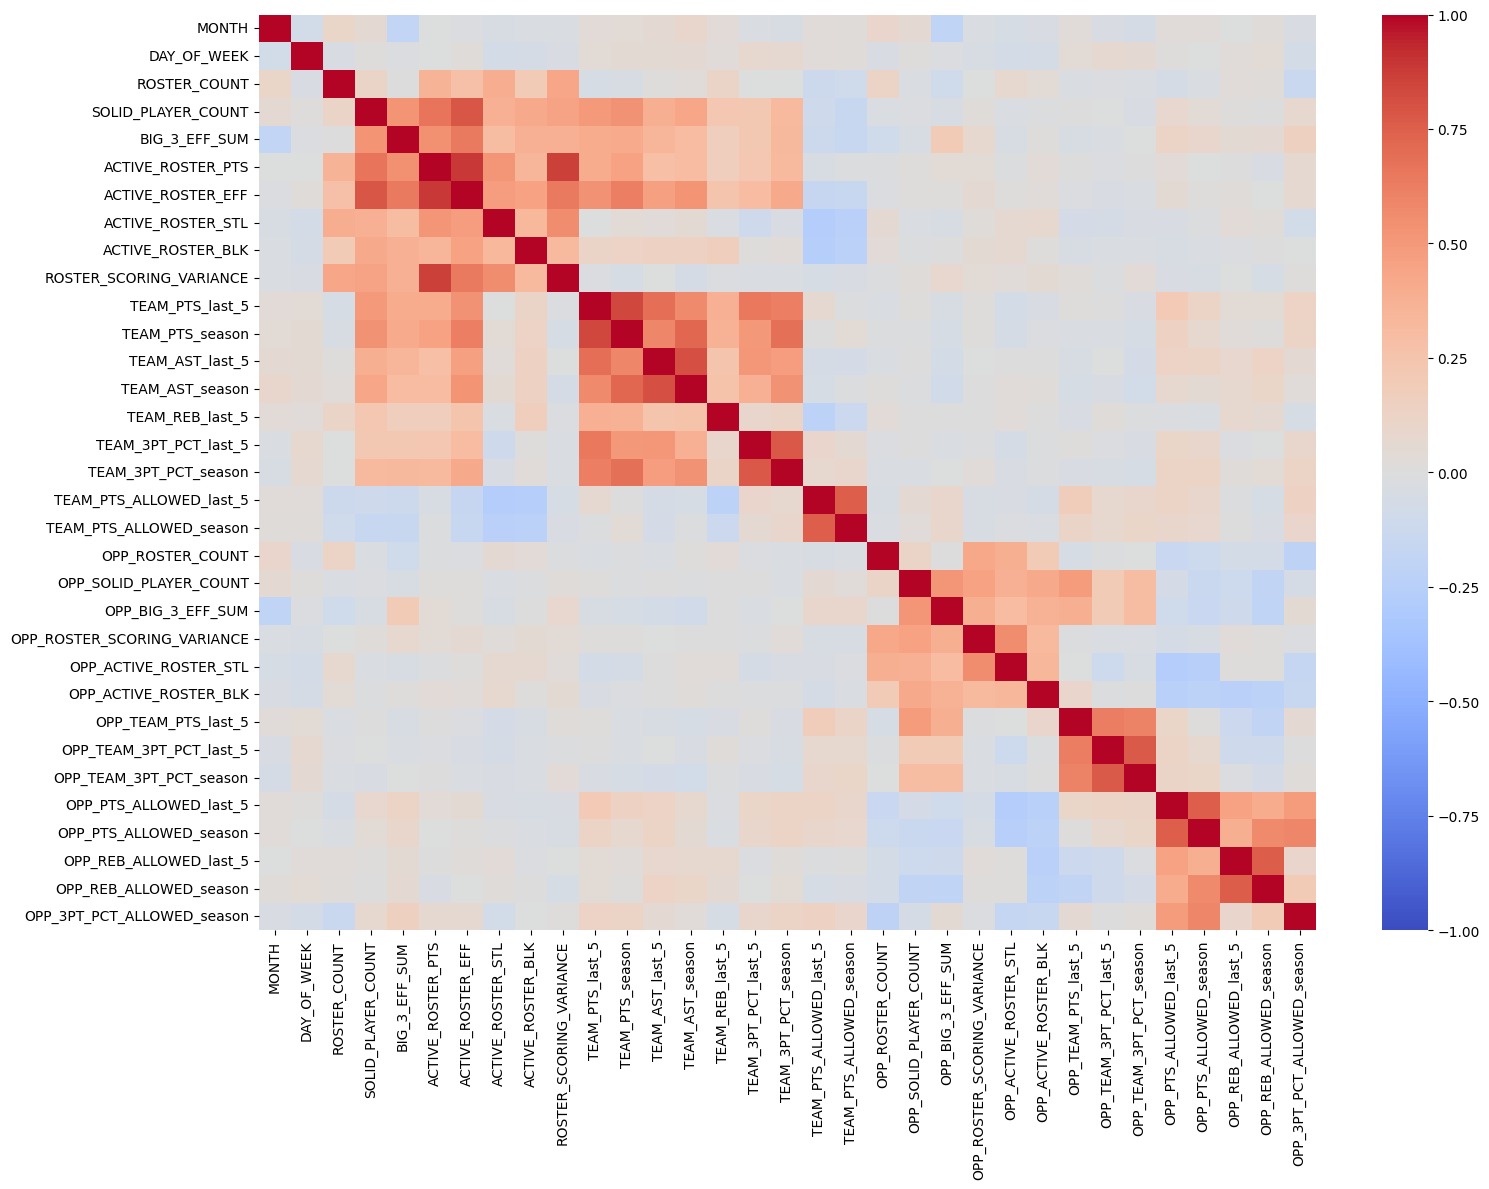

In [23]:
# Compute the correlation matrix 
correlation_matrix = x_predictors.corr()

# Plot the correlation matrix
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.tight_layout()
plt.show()


## VIF (Variance Inflation Factor)

**What it does:** For each feature, regresses it against all other features and measures how well they explain it.

**Why:** The heatmap shows pairwise correlations. VIF catches group redundancy — feature C might look independent from A and B individually, but A+B together can perfectly predict C.

**How to interpret:**
- VIF = 1 → fully independent, no redundancy
- VIF 1–5 → acceptable
- VIF 5–10 → moderate, worth investigating
- VIF > 10 → redundant, consider dropping

**Rule of thumb for XGBoost:** act on VIF > 10. Between 5–10, only drop if the feature is conceptually redundant with another you're keeping.


In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = x_predictors.columns
vif_data['VIF'] = [variance_inflation_factor(x_predictors.values, i) for i in range(x_predictors.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
vif_data


/Users/nikos/basketball-stats/.venv/lib/python3.9/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,ROSTER_SCORING_VARIANCE,inf
1,ACTIVE_ROSTER_PTS,inf
2,TEAM_PTS_season,inf
3,TEAM_PTS_last_5,491.871134
4,OPP_REB_ALLOWED_season,403.832221
5,OPP_PTS_ALLOWED_season,364.120350
6,OPP_REB_ALLOWED_last_5,330.695981
7,OPP_PTS_ALLOWED_last_5,249.148045
8,TEAM_PTS_ALLOWED_season,218.938357
9,TEAM_PTS_ALLOWED_last_5,200.311830


## Notes

**Correlation Heatmap (feature vs feature)**
- Revealed 3 correlated clusters: roster quality, team form, opponent mirrors
- `last_5` and `season` versions of the same stat were consistently correlated

**VIF**
- Quantified redundancy beyond pairwise correlations
- `ROSTER_SCORING_VARIANCE`, `ACTIVE_ROSTER_PTS`, `TEAM_PTS_season` → inf VIF (perfect linear combinations of other features) → drop
- Most `last_5`/`season` pairs had VIF > 100 → kept `last_5`, dropped `season`

### Result
Reduce features from ~35 predictors to ~25 to improve model.